# Extract transaction data with PaddleOCR

This notebook runs local OCR on cropped transaction images using PaddleOCR's PP-OCRv5 server detection and recognition models. A dataset selector lets you switch between a small test set and the complete crop set. The first model run downloads the pretrained files; subsequent inference can run offline from the local model cache.

## Import dependencies and locate the repository

Run this notebook with the `transactionsViz` kernel after installing `paddlepaddle` and `paddleocr`.

In [24]:
from pathlib import Path

import paddle
import paddleocr
from IPython.display import display
from paddleocr import PaddleOCR
from PIL import Image

print(f"PaddlePaddle version: {paddle.__version__}")
print(f"PaddleOCR version: {paddleocr.__version__}")

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

PaddlePaddle version: 3.2.0
PaddleOCR version: 3.7.0


## Select the dataset

Change only `dataset_name` to switch between the small test crop set and the complete crop set. The selected dataset controls the preview image, batch input folder, and output folder. `actual` is the default for the full run.

[2026-08-05 20:24:39,659] [   ERROR] base_events.py:1833 - Task was destroyed but it is pending!
task: <Task pending name='Task-320' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Johnson\miniforge3\envs\transactionsViz\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-321' coro=<Kernel.shell_main() running at C:\Users\Johnson\miniforge3\envs\transactionsViz\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Johnson\miniforge3\envs\transactionsViz\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Johnson\miniforge3\envs\transactionsViz\Lib\pathlib.py:176: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _select_from(self, parent_path, scandir):
[2026-08-05 20:24:39,674] [   ERROR] base_events.py:1833 - Task was destroyed but it is pending!
task: <Task pending name='Task-321' coro=<Kernel.shell_main() running at C:\Users\

Dataset: actual
Images found: 153
Preview image: C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\images\crops\Screenshot_20260805_111339_alternating_bands\Screenshot_20260805_111339_band_001_y400-508.jpg
Output directory: C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339
Size: 540 x 108 pixels


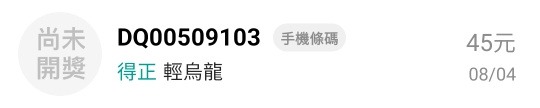

In [25]:
datasets = {
    "test": {
        "crop_folder": "Screenshot_20260805_111339_test_alternating_bands",
        "output_folder": "screenshot_20260805_111339_test",
    },
    "actual": {
        "crop_folder": "Screenshot_20260805_111339_alternating_bands",
        "output_folder": "screenshot_20260805_111339",
    },
}

dataset_name = "actual"  # Change to "test" for the smaller test run.
if dataset_name not in datasets:
    raise ValueError(f"dataset_name must be one of: {', '.join(datasets)}")

dataset = datasets[dataset_name]
input_dir = repo_root / "images" / "crops" / dataset["crop_folder"]
output_dir = repo_root / "outputs" / "ocr" / dataset["output_folder"]
image_paths = sorted(input_dir.glob("*.jpg"))

if not image_paths:
    raise FileNotFoundError(f"No JPG crops found in {input_dir}")

image_path = image_paths[0]

with Image.open(image_path) as source:
    crop = source.copy()

print(f"Dataset: {dataset_name}")
print(f"Images found: {len(image_paths)}")
print(f"Preview image: {image_path}")
print(f"Output directory: {output_dir}")
print(f"Size: {crop.width} x {crop.height} pixels")
display(crop)

## Initialize the local OCR pipeline

The screenshot is already upright and undistorted, so the orientation and unwarping modules are disabled. Model initialization may take longer the first time while the weights are downloaded.

In [26]:
ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv5_server_det",
    text_recognition_model_name="PP-OCRv5_server_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device="cpu",
)

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Johnson\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Johnson\.paddlex\official_models\PP-OCRv5_server_rec`.


## Run OCR on the selected dataset's preview image

In [27]:
results = ocr.predict(str(image_path))

for result in results:
    result.print()

{'res': {'input_path': 'C:\\Users\\Johnson\\Desktop\\PersonalProjects\\TransactionsVisualizer\\images\\crops\\Screenshot_20260805_111339_alternating_bands\\Screenshot_20260805_111339_band_001_y400-508.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'dt_polys': array([[[ 35,  24],
        ...,
        [ 35,  54]],

       ...,

       [[468,  65],
        ...,
        [468,  82]]], shape=(7, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1], shape=(7,)), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['尚未', 'DQ00509103', '手機條碼', '45元', '開獎', '得正 輕烏龍', '08/04'], 'rec_scores': array([0.99645245, ..., 0.99977082], shape=(7,)), 'rec_polys': array([[[ 35,  24],
        ...,
        [ 35,  54]],

       ...,

       [[468,

## Run OCR on every image in the selected dataset

Generated artifacts are kept outside the source-image tree under the selected dataset's run folder in `outputs/ocr/`. The run folder contains raw PaddleOCR JSON, annotated preview images, a detection-level CSV, and an image-level summary CSV. Test and actual outputs use separate folders, so switching datasets does not overwrite the other run.

In [28]:
import pandas as pd

raw_json_dir = output_dir / "raw_json"
annotated_dir = output_dir / "annotated_images"
raw_json_dir.mkdir(parents=True, exist_ok=True)
annotated_dir.mkdir(parents=True, exist_ok=True)

print(f"Selected dataset: {dataset_name}")
print(f"Found {len(image_paths)} images in {input_dir}")
print(f"Output directory: {output_dir}")

Selected dataset: actual
Found 153 images in C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\images\crops\Screenshot_20260805_111339_alternating_bands
Output directory: C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339


### Collect text, confidence scores, and coordinates

The detection-level table retains one row per recognized text box. Coordinates are preserved because they will let us assign text to receipt code, store/description, amount, and date fields in the next step. The summary table provides one row per source image for convenient review.

In [29]:
detection_rows = []
summary_rows = []

for current_number, current_path in enumerate(image_paths, start=1):
    image_results = ocr.predict(str(current_path))

    for result in image_results:
        # Preserve PaddleOCR's complete output and a visual bounding-box preview.
        result.save_to_json(str(raw_json_dir))
        result.save_to_img(str(annotated_dir))

        payload = result.json
        data = payload.get("res", payload)
        texts = data.get("rec_texts", [])
        scores = data.get("rec_scores", [])
        boxes = data.get("rec_boxes", [])

        for detection_index, (text, score, box) in enumerate(
            zip(texts, scores, boxes), start=1
        ):
            x_min, y_min, x_max, y_max = (int(value) for value in box)
            detection_rows.append(
                {
                    "source_image": current_path.name,
                    "detection_index": detection_index,
                    "text": text,
                    "confidence": float(score),
                    "x_min": x_min,
                    "y_min": y_min,
                    "x_max": x_max,
                    "y_max": y_max,
                }
            )

        numeric_scores = [float(score) for score in scores]
        summary_rows.append(
            {
                "source_image": current_path.name,
                "detected_text_count": len(texts),
                "combined_text": " | ".join(texts),
                "mean_confidence": (
                    sum(numeric_scores) / len(numeric_scores) if numeric_scores else None
                ),
            }
        )

    print(f"[{current_number:02d}/{len(image_paths):02d}] {current_path.name}")

[01/153] Screenshot_20260805_111339_band_001_y400-508.jpg
[02/153] Screenshot_20260805_111339_band_002_y510-617.jpg
[03/153] Screenshot_20260805_111339_band_003_y619-727.jpg
[04/153] Screenshot_20260805_111339_band_004_y729-836.jpg
[05/153] Screenshot_20260805_111339_band_005_y838-946.jpg
[06/153] Screenshot_20260805_111339_band_006_y948-1055.jpg
[07/153] Screenshot_20260805_111339_band_007_y1057-1165.jpg
[08/153] Screenshot_20260805_111339_band_008_y1167-1274.jpg
[09/153] Screenshot_20260805_111339_band_009_y1276-1384.jpg
[10/153] Screenshot_20260805_111339_band_010_y1386-1493.jpg
[11/153] Screenshot_20260805_111339_band_011_y1495-1603.jpg
[12/153] Screenshot_20260805_111339_band_012_y1605-1712.jpg
[13/153] Screenshot_20260805_111339_band_013_y1714-1822.jpg
[14/153] Screenshot_20260805_111339_band_014_y1824-1931.jpg
[15/153] Screenshot_20260805_111339_band_015_y1933-2041.jpg
[16/153] Screenshot_20260805_111339_band_016_y2043-2150.jpg
[17/153] Screenshot_20260805_111339_band_017_y2152-

### Export the CSV files

`utf-8-sig` preserves Traditional Chinese text and also makes the files easier to open directly in Microsoft Excel.

In [30]:
detections_df = pd.DataFrame(detection_rows)
summary_df = pd.DataFrame(summary_rows)

detections_csv = output_dir / "ocr_detections.csv"
summary_csv = output_dir / "ocr_image_summary.csv"
detections_df.to_csv(detections_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print(f"Saved {len(detections_df)} detections to {detections_csv}")
print(f"Saved {len(summary_df)} image summaries to {summary_csv}")
display(summary_df)
display(detections_df.head(20))

Saved 1055 detections to C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339\ocr_detections.csv
Saved 153 image summaries to C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339\ocr_image_summary.csv


,source_image,detected_text_count,combined_text,mean_confidence
0,Screenshot_20260805_111339_band_001_y400-508.jpg,7,尚未 | DQ00509103 | 手機條碼 | 45元 | 開獎 | 得正 輕烏龍 | 0...,0.986583
1,Screenshot_20260805_111339_band_002_y510-617.jpg,7,尚未 | CJ65374262 | 手機條碼 | 178元 | 開獎 | 全家 明細更新中，...,0.985932
2,Screenshot_20260805_111339_band_003_y619-727.jpg,7,尚未 | CJ65374275 | 手機條碼 | 197元 | 開獎 | 全家 明細更新中，...,0.986191
3,Screenshot_20260805_111339_band_004_y729-836.jpg,8,尚未 | DH17234686 | 手機條碼 | 45元 | 開獎 | 路易莎咖啡R | 錫...,0.966527
4,Screenshot_20260805_111339_band_005_y838-946.jpg,7,尚未 | DM66256508 | 纸本電子 | 20元 | 開獎 | 萬洲通國際企...置...,0.959596
...,...,...,...,...
148,Screenshot_20260805_111339_band_149_y16606-167...,5,尚未 | CD78157036 | 傳統發票 | 開獎 | 07-08月,0.972771
149,Screenshot_20260805_111339_band_150_y16716-168...,5,尚未 | CD78789694 | 傳統發票 | 開獎 | 07-08月,0.972331
150,Screenshot_20260805_111339_band_151_y16825-169...,0,,NaN
151,Screenshot_20260805_111339_band_152_y16935-170...,3,消费分析 | 日 | 0,0.627001


,source_image,detection_index,text,confidence,x_min,y_min,x_max,y_max
0,Screenshot_20260805_111339_band_001_y400-508.jpg,1,尚未,0.996452,35,24,87,54
1,Screenshot_20260805_111339_band_001_y400-508.jpg,2,DQ00509103,0.999345,116,25,261,48
2,Screenshot_20260805_111339_band_001_y400-508.jpg,3,手機條碼,0.940612,277,25,341,48
3,Screenshot_20260805_111339_band_001_y400-508.jpg,4,45元,0.999581,463,28,518,56
4,Screenshot_20260805_111339_band_001_y400-508.jpg,5,開獎,0.970713,34,53,87,83
5,Screenshot_20260805_111339_band_001_y400-508.jpg,6,得正 輕烏龍,0.999603,115,60,223,83
6,Screenshot_20260805_111339_band_001_y400-508.jpg,7,08/04,0.999771,468,65,516,82
7,Screenshot_20260805_111339_band_002_y510-617.jpg,1,尚未,0.996928,34,21,88,55
8,Screenshot_20260805_111339_band_002_y510-617.jpg,2,CJ65374262,0.999947,116,25,258,47
9,Screenshot_20260805_111339_band_002_y510-617.jpg,3,手機條碼,0.955913,275,27,337,47


## Split store name (teal) from description (black)

PaddleOCR often recognizes the lower row as one text box. Instead of splitting that text on spaces, the following code detects the horizontal extent of teal pixels and uses it to create separate store-name and description regions. Each region is then OCRed independently.

The coordinate limits are intentionally tailored to these 540-pixel-wide transaction crops: the useful lower row begins near `x=100`, while the date begins to the right of `x=455`.

In [31]:
import numpy as np


def find_store_and_description_boxes(image):
    """Return crop boxes for the teal store name and black description."""
    rgb = np.asarray(image.convert("RGB"))
    height, width = rgb.shape[:2]

    # Restrict color detection to the lower transaction-text row.
    row_top = min(45, height)
    row_bottom = height
    content_left = min(100, width)
    content_right = min(455, width)  # Exclude the date on the right.
    region = rgb[row_top:row_bottom, content_left:content_right]

    if region.size == 0:
        return None, None

    red = region[:, :, 0].astype(int)
    green = region[:, :, 1].astype(int)
    blue = region[:, :, 2].astype(int)

    # Teal letters have much stronger green/blue channels than red.
    teal_mask = (green > 90) & (blue > 80) & ((green - red) > 25) & ((blue - red) > 15)
    _, teal_x = np.where(teal_mask)

    if teal_x.size == 0:
        return None, None

    teal_left = content_left + int(teal_x.min())
    teal_right = content_left + int(teal_x.max()) + 1

    # Small margins retain antialiased letter edges without including much
    # text from the neighboring region.
    store_box = (max(content_left, teal_left - 4), row_top, min(content_right, teal_right + 4), row_bottom)
    description_left = min(content_right, teal_right + 5)
    description_box = (description_left, row_top, content_right, row_bottom)
    return store_box, description_box


def ocr_box(image, box, scale=3):
    """OCR one image region and return its combined text and mean confidence."""
    if box is None or box[2] - box[0] < 5 or box[3] - box[1] < 5:
        return "", None

    region = image.crop(box)
    enlarged = region.resize(
        (region.width * scale, region.height * scale),
        Image.Resampling.LANCZOS,
    )
    region_results = ocr.predict(np.asarray(enlarged))

    texts = []
    scores = []
    for result in region_results:
        payload = result.json
        data = payload.get("res", payload)
        for text, score in zip(data.get("rec_texts", []), data.get("rec_scores", [])):
            if text.strip():
                texts.append(text)
                scores.append(float(score))

    mean_score = sum(scores) / len(scores) if scores else None
    return " ".join(texts), mean_score

### Preview the detected split on one image

Inspect this preview before processing the full folder. The first image should show only the teal store name in the left preview and only the black purchased-item description in the right preview. If a future screenshot uses different colors or spacing, adjust the thresholds and coordinate limits above.

Store box: (114, 45, 160, 108)
Description box: (161, 45, 455, 108)


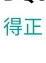

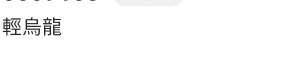

Store: '得正' (confidence=0.9997798800468445)
Description: '輕烏龍' (confidence=0.9997258186340332)


In [32]:
with Image.open(image_paths[0]) as source:
    sample_image = source.convert("RGB")

sample_store_box, sample_description_box = find_store_and_description_boxes(sample_image)
print(f"Store box: {sample_store_box}")
print(f"Description box: {sample_description_box}")
display(sample_image.crop(sample_store_box))
display(sample_image.crop(sample_description_box))

sample_store_text, sample_store_confidence = ocr_box(sample_image, sample_store_box)
sample_description_text, sample_description_confidence = ocr_box(
    sample_image, sample_description_box
)
print(f"Store: {sample_store_text!r} (confidence={sample_store_confidence})")
print(f"Description: {sample_description_text!r} (confidence={sample_description_confidence})")

### Extract both fields for every image and update the summary CSV

In [33]:
split_rows = []

for current_number, current_path in enumerate(image_paths, start=1):
    with Image.open(current_path) as source:
        current_image = source.convert("RGB")

    store_box, description_box = find_store_and_description_boxes(current_image)
    store_name, store_confidence = ocr_box(current_image, store_box)
    description, description_confidence = ocr_box(current_image, description_box)

    split_rows.append(
        {
            "source_image": current_path.name,
            "store_name": store_name,
            "description": description,
            "store_confidence": store_confidence,
            "description_confidence": description_confidence,
        }
    )
    print(f"[{current_number:02d}/{len(image_paths):02d}] {store_name!r} | {description!r}")

split_df = pd.DataFrame(split_rows)
summary_df = summary_df.drop(
    columns=["store_name", "description", "store_confidence", "description_confidence"],
    errors="ignore",
).merge(split_df, on="source_image", how="left")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print(f"Updated {summary_csv}")
display(
    summary_df[["source_image", "store_name", "description", "store_confidence", "description_confidence"]]
)

[01/153] '得正' | '輕烏龍'
[02/153] '全家' | '明細更新中，請稍候'
[03/153] '全家' | '明細更新中，請稍候'
[04/153] '路易莎咖啡' | 'R 錫蘭紅茶-大冰'
[05/153] '萬洲通國際企...置物箱使' | '用费'
[06/153] '得正' | '焙烏龍'
[07/153] 'Miacuc...' | '超級蛋白質佛陀碗'
[08/153] '屈臣氏' | 'L，EGERE100蘆薈保濕..'
[09/153] '路易莎咖啡' | 'BMS黑糖雪點奶茶一.'
[10/153] '廣三崇光國際...Kinokuni' | 'ya'
[11/153] '敦煌書局' | '黃阿瑪的後宮生活：後宮..'
[12/153] '八曜和茶' | '續一輪小菜'
[13/153] '全家' | '台鹽海洋鹼性離子水'
[14/153] '花灑果食有限...' | '自取-檸檬千層蛋..'
[15/153] '實境共創股份...' | '檸檬冰棒'
[16/153] '7-ELEV...' | '(A)*台鹽海洋鹼性離子水P.'
[17/153] '7-ELEV...' | '小龍蝦沙拉三明治'
[18/153] 'Miacuc...' | '酪梨滷肉飯'
[19/153] '實境共創股份...' | '恐龍園區限定造型..'
[20/153] '泰初安安商行...' | '原味蛋餅-辣'
[21/153] 'Miacuc...' | '三杯佛陀碗'
[22/153] '得正' | '焙烏龍'
[23/153] '7-ELEV...' | '統一麥香奶茶雪糕'
[24/153] '康是美' | 'R)撒隆巴斯-愛小型20片裝'
[25/153] '7-ELEV...' | '杜老爺玉井情人果大脆冰棒'
[26/153] '得正' | '春烏龍'
[27/153] '卡藍智飲有限...' | '嫩雞能量沙拉'
[28/153] '京站時尚廣場...' | '食品'
[29/153] '全家' | '福樂Q果草莓芝芝優酪雪糕'
[30/153] '京站時尚廣場...' | '食品'
[31/153] '松山運動中心...' | 'ZUMBA'
[32/153] '得正' | '紅茶'
[33/153] '泰初安安商行..

,source_image,store_name,description,store_confidence,description_confidence
0,Screenshot_20260805_111339_band_001_y400-508.jpg,得正,輕烏龍,0.999780,0.999726
1,Screenshot_20260805_111339_band_002_y510-617.jpg,全家,明細更新中，請稍候,0.999749,0.993204
2,Screenshot_20260805_111339_band_003_y619-727.jpg,全家,明細更新中，請稍候,0.999404,0.996181
3,Screenshot_20260805_111339_band_004_y729-836.jpg,路易莎咖啡,R 錫蘭紅茶-大冰,0.998455,0.928871
4,Screenshot_20260805_111339_band_005_y838-946.jpg,萬洲通國際企...置物箱使,用费,0.799534,0.821270
...,...,...,...,...,...
148,Screenshot_20260805_111339_band_149_y16606-167...,,,NaN,NaN
149,Screenshot_20260805_111339_band_150_y16716-168...,,,NaN,NaN
150,Screenshot_20260805_111339_band_151_y16825-169...,,,NaN,NaN
151,Screenshot_20260805_111339_band_152_y16935-170...,目,,0.370785,NaN


## Extract receipt code, amount, and purchase date

A typical `combined_text` value has seven segments separated by six pipes:

```text
status | receipt code | barcode type | amount | prize status | store/description | date
```

The number of intermediate OCR segments can vary. The stable positions are the second segment for the receipt code, the fourth for the amount, and the final segment for the date. The parser strips all non-digits from the amount, stores it as a nullable integer, and converts `MM/DD` into a pandas datetime using 2026 as the year. A row too short to contain these positions receives missing values and `parse_valid=False`.

In [34]:
import re


def parse_combined_text(combined_text, year=2026):
    parts = [part.strip() for part in str(combined_text).split("|")]
    if len(parts) < 5:
        return {
            "receipt_code": None,
            "amount": None,
            "date": pd.NaT,
            "parse_valid": False,
        }

    receipt_code = parts[1]
    amount_digits = re.sub(r"[^0-9]", "", parts[3])
    purchase_date = pd.to_datetime(
        f"{year}/{parts[-1]}",
        format="%Y/%m/%d",
        errors="coerce",
    )

    parse_valid = bool(receipt_code and amount_digits and not pd.isna(purchase_date))
    return {
        "receipt_code": receipt_code or None,
        "amount": int(amount_digits) if amount_digits else None,
        "date": purchase_date,
        "parse_valid": parse_valid,
    }


parsed_df = summary_df["combined_text"].apply(parse_combined_text).apply(pd.Series)
summary_df = summary_df.drop(
    columns=["receipt_code", "amount", "date", "parse_valid"],
    errors="ignore",
).join(parsed_df)
summary_df["amount"] = summary_df["amount"].astype("Int64")
summary_df["date"] = pd.to_datetime(summary_df["date"])

# ISO-formatted dates are unambiguous when the CSV is opened elsewhere.
summary_df.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

invalid_count = int((~summary_df["parse_valid"]).sum())
print(f"Updated {summary_csv}")
print(f"Rows requiring review: {invalid_count}")
display(
    summary_df[
        ["source_image", "receipt_code", "store_name", "description", "amount", "date", "parse_valid"]
    ]
)

Updated C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339\ocr_image_summary.csv
Rows requiring review: 7


,source_image,receipt_code,store_name,description,amount,date,parse_valid
0,Screenshot_20260805_111339_band_001_y400-508.jpg,DQ00509103,得正,輕烏龍,45,2026-08-04,True
1,Screenshot_20260805_111339_band_002_y510-617.jpg,CJ65374262,全家,明細更新中，請稍候,178,2026-08-04,True
2,Screenshot_20260805_111339_band_003_y619-727.jpg,CJ65374275,全家,明細更新中，請稍候,197,2026-08-04,True
3,Screenshot_20260805_111339_band_004_y729-836.jpg,DH17234686,路易莎咖啡,R 錫蘭紅茶-大冰,45,2026-08-03,True
4,Screenshot_20260805_111339_band_005_y838-946.jpg,DM66256508,萬洲通國際企...置物箱使,用费,20,2026-08-03,True
...,...,...,...,...,...,...,...
148,Screenshot_20260805_111339_band_149_y16606-167...,CD78157036,,,<NA>,NaT,False
149,Screenshot_20260805_111339_band_150_y16716-168...,CD78789694,,,<NA>,NaT,False
150,Screenshot_20260805_111339_band_151_y16825-169...,NaN,,,<NA>,NaT,False
151,Screenshot_20260805_111339_band_152_y16935-170...,NaN,目,,<NA>,NaT,False
